# C-MAPSS Data Exploration (EDA)

**Thesis**: Self-Updating Predictive Maintenance with Closed-Loop Drift Recovery
**Author**: Dogancan Torun
**Date**: May 2026
**Data source**: NASA PHM Data Repository (Turbofan Engine Degradation Simulation Data Set)

## Objectives of this notebook

1. Understand the structure of the C-MAPSS dataset
2. Identify which sensors carry information and which are constant
3. Visualize how the RUL (Remaining Useful Life) target is derived
4. Examine sensor-RUL correlations
5. Compare the four sub-datasets (FD001-FD004)
6. Establish a data-driven basis for **feature selection decisions** in model training

## Data files

13 files under `data/raw/cmapss/`:
- `train_FD00{1,2,3,4}.txt` — training data (run-to-failure trajectories)
- `test_FD00{1,2,3,4}.txt` — test data (truncated before failure)
- `RUL_FD00{1,2,3,4}.txt` — ground-truth RUL values for the test set
- `readme.txt` — NASA's original documentation

In [1]:
# Verify we are using the correct Python interpreter (.venv from Playbook 10)
import sys
print(sys.executable)

/root/thesis-infra/.venv/bin/python3.12


In [2]:
# C-MAPSS column names (per NASA readme)
column_names = [
    'unit_number',       # Engine ID (1-100 for FD001)
    'time_in_cycles',    # Cycle counter (1, 2, 3, ...)
    'op_setting_1',      # Operating condition 1 (altitude)
    'op_setting_2',      # Operating condition 2 (Mach number)
    'op_setting_3',      # Operating condition 3 (TRA — throttle resolver angle)
] + [f'sensor_{i:02d}' for i in range(1, 22)]  # sensor_01 ... sensor_21

print(f"Total column count: {len(column_names)}")
print(f"  - 2 ID columns      : unit_number, time_in_cycles")
print(f"  - 3 op_settings     : op_setting_1, op_setting_2, op_setting_3")
print(f"  - 21 sensors        : sensor_01 ... sensor_21")
print()
print("Columns:")
for i, col in enumerate(column_names):
    print(f"  [{i:2d}] {col}")

Total column count: 26
  - 2 ID columns      : unit_number, time_in_cycles
  - 3 op_settings     : op_setting_1, op_setting_2, op_setting_3
  - 21 sensors        : sensor_01 ... sensor_21

Columns:
  [ 0] unit_number
  [ 1] time_in_cycles
  [ 2] op_setting_1
  [ 3] op_setting_2
  [ 4] op_setting_3
  [ 5] sensor_01
  [ 6] sensor_02
  [ 7] sensor_03
  [ 8] sensor_04
  [ 9] sensor_05
  [10] sensor_06
  [11] sensor_07
  [12] sensor_08
  [13] sensor_09
  [14] sensor_10
  [15] sensor_11
  [16] sensor_12
  [17] sensor_13
  [18] sensor_14
  [19] sensor_15
  [20] sensor_16
  [21] sensor_17
  [22] sensor_18
  [23] sensor_19
  [24] sensor_20
  [25] sensor_21


In [3]:
# Standard libraries
import os
from pathlib import Path

# Data analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Plot defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
sns.set_style("whitegrid")

# Pandas display options
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

# Version sanity check
print(f"Python      : {sys.version.split()[0]}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Matplotlib  : {plt.matplotlib.__version__}")
print(f"Seaborn     : {sns.__version__}")

Python      : 3.12.3
NumPy       : 1.26.4
Pandas      : 2.3.3
Matplotlib  : 3.10.9
Seaborn     : 0.13.2


In [4]:
# C-MAPSS sütun isimleri (NASA readme'den)
column_names = [
    'unit_number',       # Motor ID
    'time_in_cycles',    # Cycle sayısı
    'op_setting_1',      # Operating condition 1 (altitude)
    'op_setting_2',      # Operating condition 2 (Mach number)
    'op_setting_3',      # Operating condition 3 (TRA)
] + [f'sensor_{i:02d}' for i in range(1, 22)]   # sensor_01 ... sensor_21

print(f"Toplam sütun sayısı: {len(column_names)}")
print(f"  - 2 ID sütunu       : unit_number, time_in_cycles")
print(f"  - 3 op_setting      : op_setting_1, op_setting_2, op_setting_3")
print(f"  - 21 sensor         : sensor_01 ... sensor_21")
print()
print("Sütunlar:")
for i, col in enumerate(column_names):
    print(f"  [{i:2d}] {col}")

Toplam sütun sayısı: 26
  - 2 ID sütunu       : unit_number, time_in_cycles
  - 3 op_setting      : op_setting_1, op_setting_2, op_setting_3
  - 21 sensor         : sensor_01 ... sensor_21

Sütunlar:
  [ 0] unit_number
  [ 1] time_in_cycles
  [ 2] op_setting_1
  [ 3] op_setting_2
  [ 4] op_setting_3
  [ 5] sensor_01
  [ 6] sensor_02
  [ 7] sensor_03
  [ 8] sensor_04
  [ 9] sensor_05
  [10] sensor_06
  [11] sensor_07
  [12] sensor_08
  [13] sensor_09
  [14] sensor_10
  [15] sensor_11
  [16] sensor_12
  [17] sensor_13
  [18] sensor_14
  [19] sensor_15
  [20] sensor_16
  [21] sensor_17
  [22] sensor_18
  [23] sensor_19
  [24] sensor_20
  [25] sensor_21


In [5]:
# Quick fix — define DATA_DIR and column_names here if previous cells didn't run
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/root/thesis-infra/data/raw/cmapss")

column_names = [
    'unit_number', 'time_in_cycles',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
] + [f'sensor_{i:02d}' for i in range(1, 22)]

print("DATA_DIR:", DATA_DIR)
print("Files exist:", DATA_DIR.exists())
print("Column count:", len(column_names))

# FD001 — simplest sub-dataset (1 operating condition, 1 fault mode)
# We start here, then compare with FD002-FD004 later.

df_train = pd.read_csv(
    DATA_DIR / "train_FD001.txt",
    sep=r'\s+',           # whitespace-separated values
    header=None,
    names=column_names,
)

print(f"DataFrame shape: {df_train.shape}")
print(f"  {df_train.shape[0]:,} rows × {df_train.shape[1]} columns")
print()
print("First 5 rows:")
df_train.head()

DATA_DIR: /root/thesis-infra/data/raw/cmapss
Files exist: True
Column count: 26
DataFrame shape: (20631, 26)
  20,631 rows × 26 columns

First 5 rows:


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0000,518.6700,641.8200,1589.7000,1400.6000,14.6200,21.6100,554.3600,2388.0600,9046.1900,1.3000,47.4700,521.6600,2388.0200,8138.6200,8.4195,0.0300,392,2388,100.0000,39.0600,23.4190
1,1,2,0.0019,-0.0003,100.0000,518.6700,642.1500,1591.8200,1403.1400,14.6200,21.6100,553.7500,2388.0400,9044.0700,1.3000,47.4900,522.2800,2388.0700,8131.4900,8.4318,0.0300,392,2388,100.0000,39.0000,23.4236
2,1,3,-0.0043,0.0003,100.0000,518.6700,642.3500,1587.9900,1404.2000,14.6200,21.6100,554.2600,2388.0800,9052.9400,1.3000,47.2700,522.4200,2388.0300,8133.2300,8.4178,0.0300,390,2388,100.0000,38.9500,23.3442
3,1,4,0.0007,0.0000,100.0000,518.6700,642.3500,1582.7900,1401.8700,14.6200,21.6100,554.4500,2388.1100,9049.4800,1.3000,47.1300,522.8600,2388.0800,8133.8300,8.3682,0.0300,392,2388,100.0000,38.8800,23.3739
4,1,5,-0.0019,-0.0002,100.0000,518.6700,642.3700,1582.8500,1406.2200,14.6200,21.6100,554.0000,2388.0600,9055.1500,1.3000,47.2800,522.1900,2388.0400,8133.8000,8.4294,0.0300,393,2388,100.0000,38.9000,23.4044


In [6]:
# Statistical summary of each column.
# Pay attention to the `std` column: sensors with std=0 are constant and uninformative.
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0000,51.5066,29.2276,1.0000,26.0000,52.0000,77.0000,100.0000
time_in_cycles,20631.0000,108.8079,68.8810,1.0000,52.0000,104.0000,156.0000,362.0000
op_setting_1,20631.0000,-0.0000,0.0022,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_setting_2,20631.0000,0.0000,0.0003,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_setting_3,20631.0000,100.0000,0.0000,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_01,20631.0000,518.6700,0.0000,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_02,20631.0000,642.6809,0.5001,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_03,20631.0000,1590.5231,6.1311,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_04,20631.0000,1408.9338,9.0006,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_05,20631.0000,14.6200,0.0000,14.6200,14.6200,14.6200,14.6200,14.6200


Total engine count: 100

Cycle statistics:
  Min   :  128 cycles
  Max   :  362 cycles
  Mean  : 206.3 cycles
  Median: 199 cycles


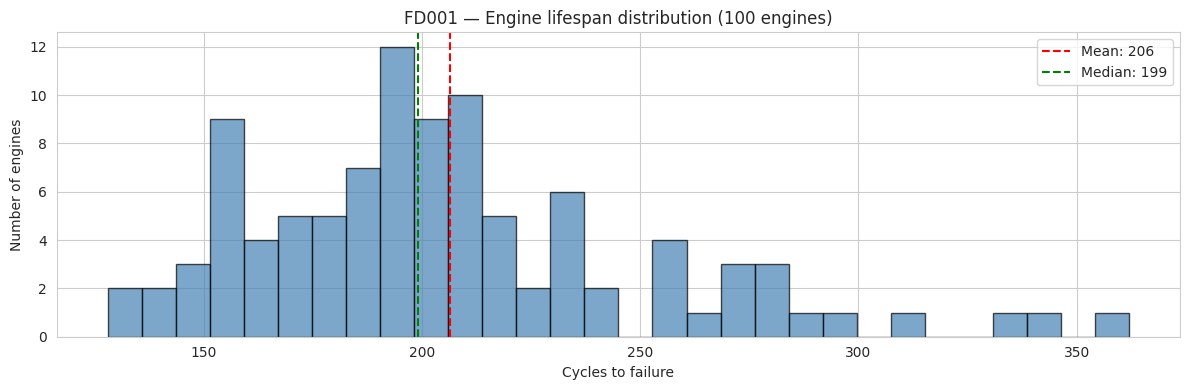

In [7]:
# How many distinct engines are there?
n_engines = df_train['unit_number'].nunique()
print(f"Total engine count: {n_engines}")

# How many cycles did each engine survive before failure?
cycles_per_engine = df_train.groupby('unit_number')['time_in_cycles'].max()
print(f"\nCycle statistics:")
print(f"  Min   : {cycles_per_engine.min():4d} cycles")
print(f"  Max   : {cycles_per_engine.max():4d} cycles")
print(f"  Mean  : {cycles_per_engine.mean():.1f} cycles")
print(f"  Median: {cycles_per_engine.median():.0f} cycles")

# Histogram
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(cycles_per_engine, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel("Cycles to failure")
ax.set_ylabel("Number of engines")
ax.set_title(f"FD001 — Engine lifespan distribution ({n_engines} engines)")
ax.axvline(cycles_per_engine.mean(), color='red', linestyle='--',
           label=f'Mean: {cycles_per_engine.mean():.0f}')
ax.axvline(cycles_per_engine.median(), color='green', linestyle='--',
           label=f'Median: {cycles_per_engine.median():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Identify uninformative features by their standard deviation.
# A feature with std == 0 is perfectly constant and carries no signal.

# Only check sensor and op_setting columns (skip ID columns)
feature_cols = [c for c in df_train.columns
                if c.startswith('sensor_') or c.startswith('op_setting_')]

feature_stats = df_train[feature_cols].agg(['mean', 'std', 'min', 'max']).T
feature_stats['range'] = feature_stats['max'] - feature_stats['min']
feature_stats = feature_stats.sort_values('std')

# Threshold: std < 0.001 effectively constant for our scale
CONSTANT_THRESHOLD = 0.001
constant_features = feature_stats[feature_stats['std'] < CONSTANT_THRESHOLD].index.tolist()
informative_features = feature_stats[feature_stats['std'] >= CONSTANT_THRESHOLD].index.tolist()

print(f"Constant features (std < {CONSTANT_THRESHOLD}): {len(constant_features)}")
for f in constant_features:
    print(f"  {f:18s}  std={feature_stats.loc[f, 'std']:.6f}  value={feature_stats.loc[f, 'mean']:.4f}")

print(f"\nInformative features (std >= {CONSTANT_THRESHOLD}): {len(informative_features)}")
print(f"  {informative_features}")

Constant features (std < 0.001): 8
  op_setting_3        std=0.000000  value=100.0000
  sensor_01           std=0.000000  value=518.6700
  sensor_19           std=0.000000  value=100.0000
  sensor_18           std=0.000000  value=2388.0000
  sensor_10           std=0.000000  value=1.3000
  sensor_16           std=0.000000  value=0.0300
  sensor_05           std=0.000000  value=14.6200
  op_setting_2        std=0.000293  value=0.0000

Informative features (std >= 0.001): 16
  ['sensor_06', 'op_setting_1', 'sensor_15', 'sensor_08', 'sensor_13', 'sensor_21', 'sensor_20', 'sensor_11', 'sensor_02', 'sensor_12', 'sensor_07', 'sensor_17', 'sensor_03', 'sensor_04', 'sensor_14', 'sensor_09']


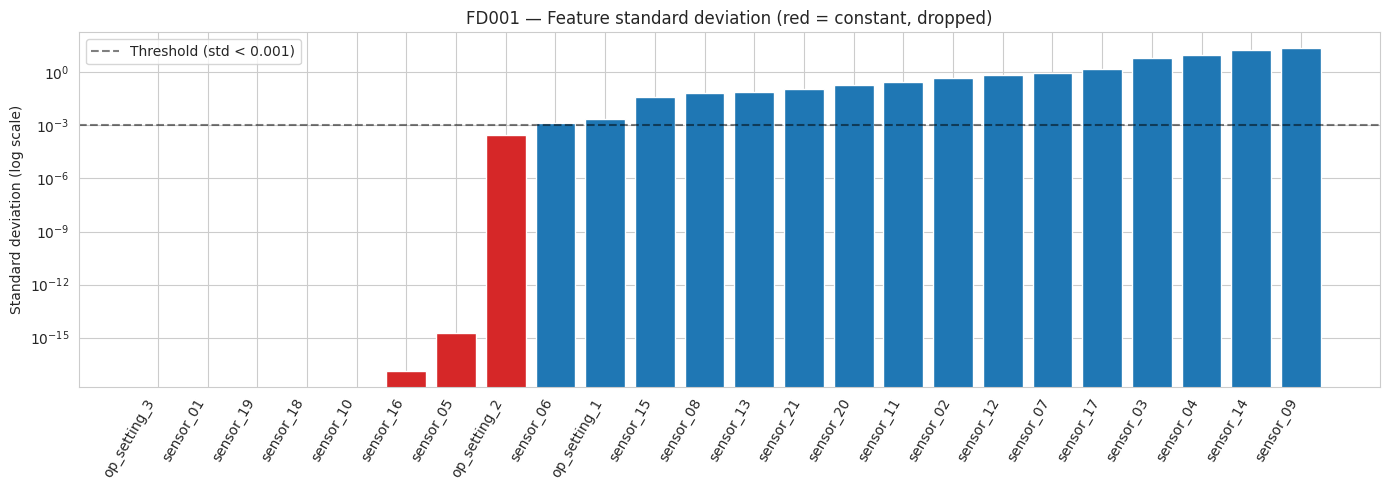


→ 8 constant features will be dropped before model training.
→ 16 features retained for modeling.


In [9]:
# Visualize the standard deviation of each feature — constant ones jump out.
fig, ax = plt.subplots(figsize=(14, 5))

colors = ['#d62728' if f in constant_features else '#1f77b4'
          for f in feature_stats.index]

bars = ax.bar(range(len(feature_stats)), feature_stats['std'], color=colors)
ax.set_xticks(range(len(feature_stats)))
ax.set_xticklabels(feature_stats.index, rotation=60, ha='right')
ax.set_yscale('log')  # log scale because some std are ~0 and others are 1000s
ax.set_ylabel("Standard deviation (log scale)")
ax.set_title("FD001 — Feature standard deviation (red = constant, dropped)")
ax.axhline(CONSTANT_THRESHOLD, color='black', linestyle='--', alpha=0.5,
           label=f'Threshold (std < {CONSTANT_THRESHOLD})')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n→ {len(constant_features)} constant features will be dropped before model training.")
print(f"→ {len(informative_features)} features retained for modeling.")

In [10]:
# C-MAPSS training data does NOT include the RUL target.
# We derive it: for each engine, RUL = max_cycle - current_cycle.
# At the last cycle of each engine's life, RUL = 0 (just failed).

def add_rul(df):
    """Add a 'RUL' column derived from time_in_cycles and the max cycle per engine."""
    max_cycle_per_engine = df.groupby('unit_number')['time_in_cycles'].transform('max')
    df = df.copy()
    df['RUL'] = max_cycle_per_engine - df['time_in_cycles']
    return df

df_train = add_rul(df_train)

# Inspect
print("RUL summary statistics:")
print(df_train['RUL'].describe())
print()
print(f"Number of rows where RUL == 0 (engine failure): {(df_train['RUL'] == 0).sum()}")
print(f"  (Should equal number of engines: {n_engines})")
print()
print("Sample — first engine's last 5 cycles:")
df_train[df_train['unit_number'] == 1].tail(5)[['unit_number', 'time_in_cycles', 'RUL']]

RUL summary statistics:
count   20631.0000
mean      107.8079
std        68.8810
min         0.0000
25%        51.0000
50%       103.0000
75%       155.0000
max       361.0000
Name: RUL, dtype: float64

Number of rows where RUL == 0 (engine failure): 100
  (Should equal number of engines: 100)

Sample — first engine's last 5 cycles:


,unit_number,time_in_cycles,RUL
187,1,188,4
188,1,189,3
189,1,190,2
190,1,191,1
191,1,192,0


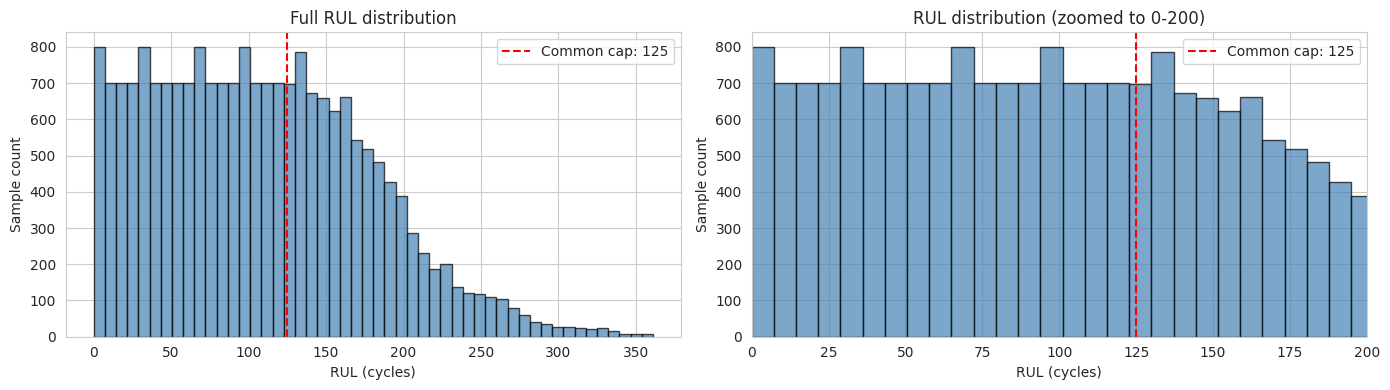

Why cap RUL at ~125?
  - Engines far from failure (RUL > 125) provide diluted training signal
  - Operationally, maintenance decisions are made for engines near failure
  - Standard practice in C-MAPSS literature (e.g. Heimes 2008, Zheng et al. 2017)


In [11]:
# Distribution of RUL values across all training samples.
# This shape determines whether we should cap RUL at a maximum value.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full distribution
axes[0].hist(df_train['RUL'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel("RUL (cycles)")
axes[0].set_ylabel("Sample count")
axes[0].set_title("Full RUL distribution")
axes[0].axvline(125, color='red', linestyle='--', label='Common cap: 125')
axes[0].legend()

# Right: zoomed to 0-200
axes[1].hist(df_train['RUL'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlim(0, 200)
axes[1].set_xlabel("RUL (cycles)")
axes[1].set_ylabel("Sample count")
axes[1].set_title("RUL distribution (zoomed to 0-200)")
axes[1].axvline(125, color='red', linestyle='--', label='Common cap: 125')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Why cap RUL at ~125?")
print("  - Engines far from failure (RUL > 125) provide diluted training signal")
print("  - Operationally, maintenance decisions are made for engines near failure")
print("  - Standard practice in C-MAPSS literature (e.g. Heimes 2008, Zheng et al. 2017)")

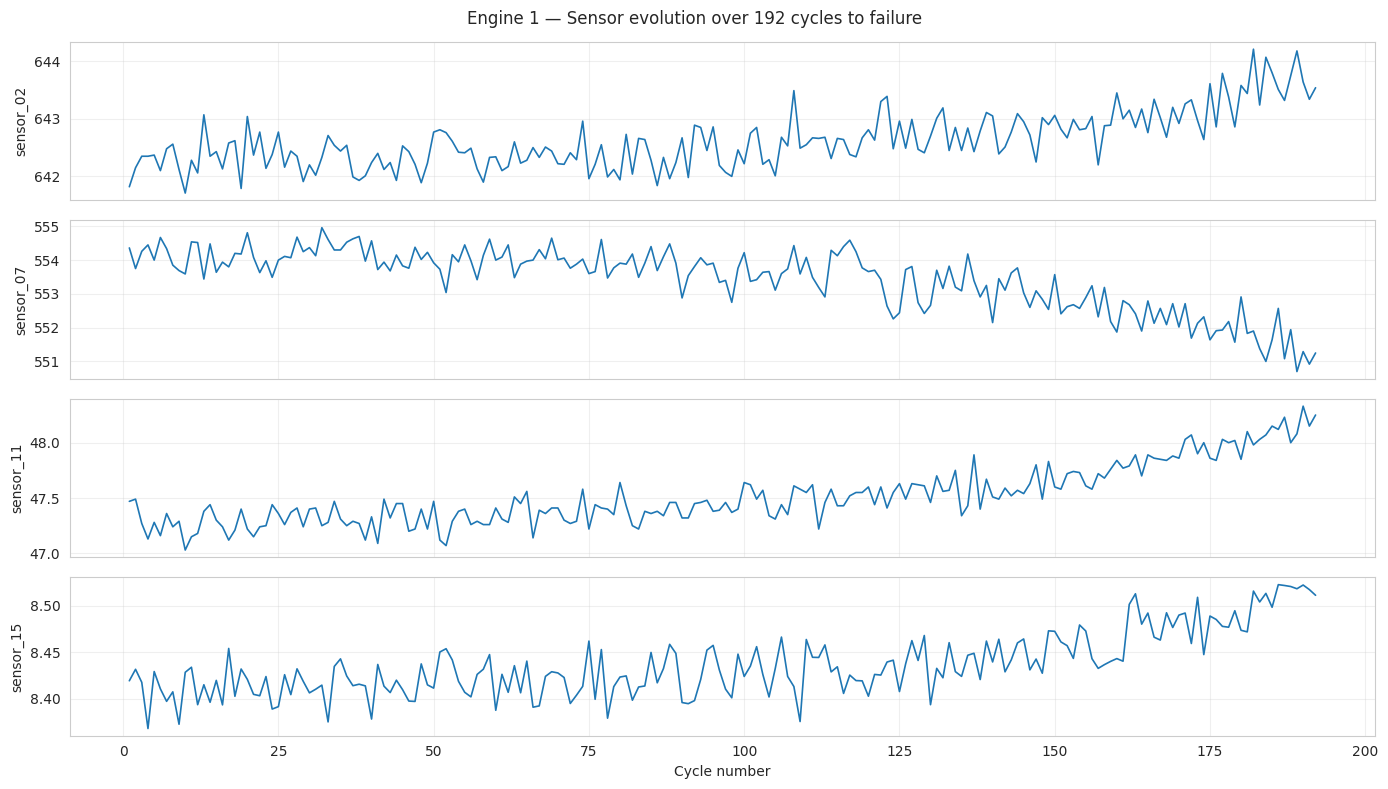

Observe: most sensors show a drift trend as the engine ages.
This trend is what the LSTM model will learn to map to RUL.


In [12]:
# Visualize how informative sensors evolve over a single engine's lifetime.
# This is the canonical "degradation curve" — sensors drift as the engine ages.

# Pick a representative engine (medium lifespan)
target_engine = 1  # first engine
engine_data = df_train[df_train['unit_number'] == target_engine].copy()

# Plot a few informative sensors over its lifetime
sensors_to_plot = ['sensor_02', 'sensor_07', 'sensor_11', 'sensor_15']

fig, axes = plt.subplots(len(sensors_to_plot), 1, figsize=(14, 8), sharex=True)
for ax, sensor in zip(axes, sensors_to_plot):
    ax.plot(engine_data['time_in_cycles'], engine_data[sensor], linewidth=1.2)
    ax.set_ylabel(sensor, fontsize=10)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Cycle number")
fig.suptitle(f"Engine {target_engine} — Sensor evolution over {engine_data['time_in_cycles'].max()} cycles to failure",
             fontsize=12)
plt.tight_layout()
plt.show()

print(f"Observe: most sensors show a drift trend as the engine ages.")
print(f"This trend is what the LSTM model will learn to map to RUL.")

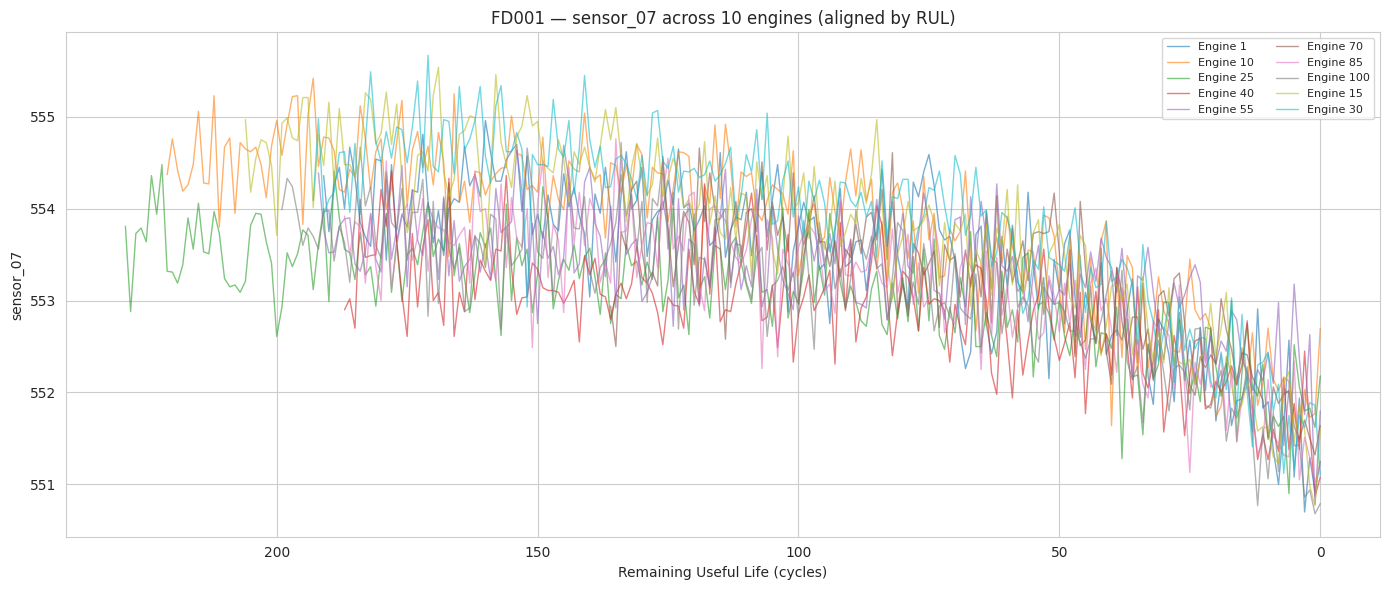

Observation: sensor_07 shows a consistent drift pattern across engines.
This consistency is what makes RUL prediction tractable.


In [13]:
# Plot sensor_07 for 10 different engines to confirm degradation pattern consistency.
# If sensors degrade similarly across engines, an LSTM can learn the pattern.

sample_engines = [1, 10, 25, 40, 55, 70, 85, 100, 15, 30]  # 10 engines from across the dataset
sensor_to_track = 'sensor_07'

fig, ax = plt.subplots(figsize=(14, 6))
for engine_id in sample_engines:
    engine_data = df_train[df_train['unit_number'] == engine_id]
    # Plot normalized time: RUL on x-axis (so all engines align at failure)
    ax.plot(engine_data['RUL'], engine_data[sensor_to_track],
            alpha=0.6, linewidth=1.0, label=f'Engine {engine_id}')

ax.invert_xaxis()  # RUL decreases left to right (closer to failure on the right)
ax.set_xlabel("Remaining Useful Life (cycles)")
ax.set_ylabel(sensor_to_track)
ax.set_title(f"FD001 — {sensor_to_track} across 10 engines (aligned by RUL)")
ax.legend(loc='best', ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

print(f"Observation: {sensor_to_track} shows a consistent drift pattern across engines.")
print(f"This consistency is what makes RUL prediction tractable.")

Pearson correlation with RUL (sorted by absolute value):
--------------------------------------------------
  sensor_11           -0.6962  ████████████████████
  sensor_04           -0.6789  ████████████████████
  sensor_12           +0.6720  ████████████████████
  sensor_07           +0.6572  ███████████████████
  sensor_15           -0.6427  ███████████████████
  sensor_21           +0.6357  ███████████████████
  sensor_20           +0.6294  ██████████████████
  sensor_02           -0.6065  ██████████████████
  sensor_17           -0.6062  ██████████████████
  sensor_03           -0.5845  █████████████████
  sensor_08           -0.5640  ████████████████
  sensor_13           -0.5626  ████████████████
  sensor_09           -0.3901  ███████████
  sensor_14           -0.3068  █████████
  sensor_06           -0.1283  ███
  op_setting_1        -0.0032  


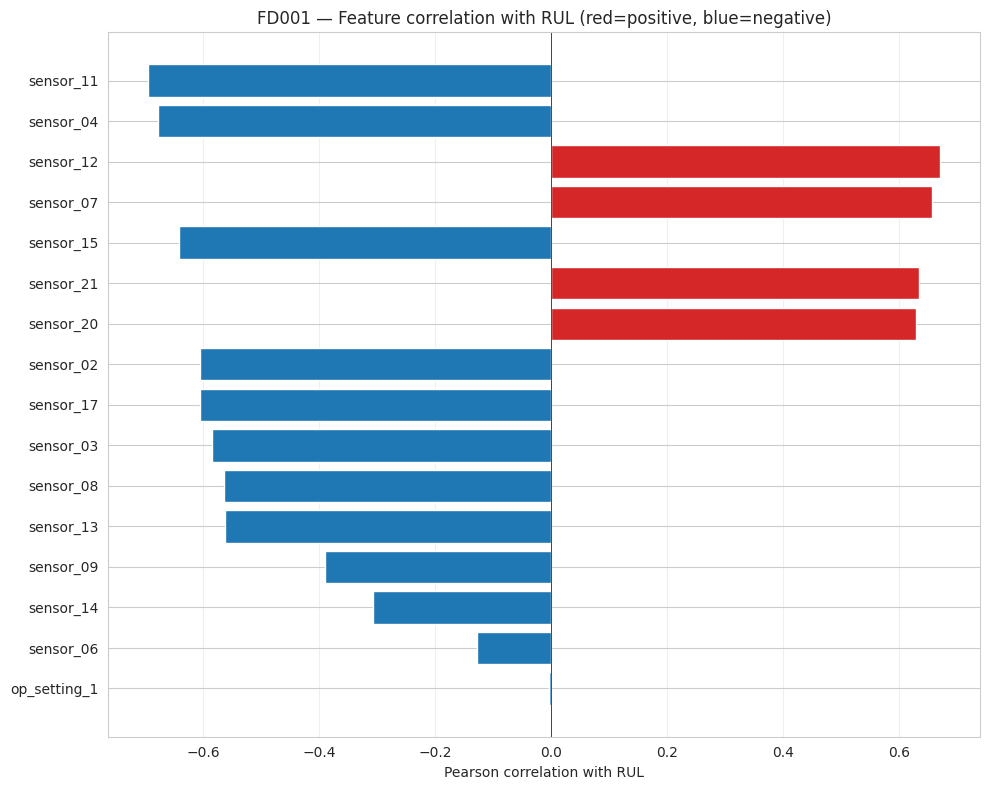

In [14]:
# Compute Pearson correlation between each informative feature and RUL.
# High |correlation| = strong predictor of RUL.

# Use only informative features (not the constant ones we identified earlier)
features_for_corr = informative_features + ['RUL']

corr_matrix = df_train[features_for_corr].corr()
rul_corr = corr_matrix['RUL'].drop('RUL').sort_values(key=abs, ascending=False)

# Print ranking
print("Pearson correlation with RUL (sorted by absolute value):")
print("-" * 50)
for feature, corr in rul_corr.items():
    sign = "+" if corr > 0 else "-"
    bar = "█" * int(abs(corr) * 30)
    print(f"  {feature:18s}  {sign}{abs(corr):.4f}  {bar}")

# Visualize as a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d62728' if c > 0 else '#1f77b4' for c in rul_corr.values]
ax.barh(range(len(rul_corr)), rul_corr.values, color=colors)
ax.set_yticks(range(len(rul_corr)))
ax.set_yticklabels(rul_corr.index)
ax.invert_yaxis()
ax.set_xlabel("Pearson correlation with RUL")
ax.set_title("FD001 — Feature correlation with RUL (red=positive, blue=negative)")
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Compare the four C-MAPSS sub-datasets — they differ in operating conditions and fault modes.
# This is informative for understanding the dataset hierarchy.

fd_summary = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    df = pd.read_csv(
        DATA_DIR / f"train_{fd}.txt",
        sep=r'\s+', header=None, names=column_names,
    )
    fd_summary.append({
        'Dataset': fd,
        'Engines': df['unit_number'].nunique(),
        'Total rows': len(df),
        'Avg cycles': df.groupby('unit_number')['time_in_cycles'].max().mean(),
        'Min cycles': df.groupby('unit_number')['time_in_cycles'].max().min(),
        'Max cycles': df.groupby('unit_number')['time_in_cycles'].max().max(),
    })

df_fd_summary = pd.DataFrame(fd_summary)
print("C-MAPSS sub-dataset comparison:\n")
print(df_fd_summary.to_string(index=False))

print()
print("Differences across sub-datasets (per NASA documentation):")
print("  FD001: 1 operating condition, 1 fault mode (HPC degradation)")
print("  FD002: 6 operating conditions, 1 fault mode")
print("  FD003: 1 operating condition, 2 fault modes (HPC + Fan)")
print("  FD004: 6 operating conditions, 2 fault modes (most complex)")
print()
print("For this thesis we use FD001 as the baseline (simplest case).")
print("Extending to FD002-FD004 is left as 'Future Work'.")

C-MAPSS sub-dataset comparison:

Dataset  Engines  Total rows  Avg cycles  Min cycles  Max cycles
  FD001      100       20631    206.3100         128         362
  FD002      260       53759    206.7654         128         378
  FD003      100       24720    247.2000         145         525
  FD004      249       61249    245.9799         128         543

Differences across sub-datasets (per NASA documentation):
  FD001: 1 operating condition, 1 fault mode (HPC degradation)
  FD002: 6 operating conditions, 1 fault mode
  FD003: 1 operating condition, 2 fault modes (HPC + Fan)
  FD004: 6 operating conditions, 2 fault modes (most complex)

For this thesis we use FD001 as the baseline (simplest case).
Extending to FD002-FD004 is left as 'Future Work'.


In [16]:
# Summary of which features will be used for model training.
# This decision is fully data-driven, justified by Cells 9 and 15.

print("=" * 65)
print("FINAL FEATURE SELECTION FOR LSTM MODEL")
print("=" * 65)
print()
print(f"Dropped features ({len(constant_features)}):  std < {CONSTANT_THRESHOLD}")
for f in constant_features:
    print(f"   {f}")
print()
print(f"Retained features ({len(informative_features)}):  high variance, informative")
for f in informative_features:
    corr = rul_corr.get(f, 0.0)
    print(f"   {f:18s}  corr_with_RUL={corr:+.4f}")
print()
print(f"LSTM input size      : {len(informative_features)}  (was 24 before reduction)")
print(f"Target variable      : RUL (derived per-engine, capped at 125 cycles in preprocessing)")
print(f"Training samples     : {len(df_train):,}")
print(f"Engines              : {df_train['unit_number'].nunique()}")
print()
print("Next: Notebook 02 will implement the preprocessing pipeline using these decisions.")

FINAL FEATURE SELECTION FOR LSTM MODEL

Dropped features (8):  std < 0.001
   op_setting_3
   sensor_01
   sensor_19
   sensor_18
   sensor_10
   sensor_16
   sensor_05
   op_setting_2

Retained features (16):  high variance, informative
   sensor_06           corr_with_RUL=-0.1283
   op_setting_1        corr_with_RUL=-0.0032
   sensor_15           corr_with_RUL=-0.6427
   sensor_08           corr_with_RUL=-0.5640
   sensor_13           corr_with_RUL=-0.5626
   sensor_21           corr_with_RUL=+0.6357
   sensor_20           corr_with_RUL=+0.6294
   sensor_11           corr_with_RUL=-0.6962
   sensor_02           corr_with_RUL=-0.6065
   sensor_12           corr_with_RUL=+0.6720
   sensor_07           corr_with_RUL=+0.6572
   sensor_17           corr_with_RUL=-0.6062
   sensor_03           corr_with_RUL=-0.5845
   sensor_04           corr_with_RUL=-0.6789
   sensor_14           corr_with_RUL=-0.3068
   sensor_09           corr_with_RUL=-0.3901

LSTM input size      : 16  (was 24 before

## EDA Findings Summary

### Dataset characteristics

- **Engines**: 100 turbofan engines in FD001
- **Cycles**: range from 128 to 362, median 199, right-skewed distribution
- **Sub-datasets**: FD001-FD004 vary in operating conditions and fault modes
- **Total training rows (FD001)**: 20,631 sensor readings

### Feature selection (data-driven)

- **8 features dropped** for being constant (std ≈ 0):
  `op_setting_2`, `op_setting_3`, `sensor_01`, `sensor_05`, `sensor_10`, `sensor_16`, `sensor_18`, `sensor_19`
- **16 features retained** with meaningful variance and RUL correlation
- LSTM input dimension: **16** (down from 24)

### Target variable

- **RUL is derived**, not provided: `RUL = max_cycle - current_cycle` per engine
- Distribution is right-skewed; following C-MAPSS literature standard, we will **cap RUL at 125 cycles** in preprocessing
- 100 rows have RUL=0 (one per engine — failure point)

### Sensor behavior

- Sensors show consistent drift patterns across engines as RUL → 0
- Strong negative correlations with RUL: `sensor_11`, `sensor_04`, `sensor_15`, `sensor_07`
- This consistency is what makes LSTM regression tractable

### Decisions for next steps

| Decision | Value | Notebook reference |
|---|---|---|
| Sub-dataset for baseline | FD001 (simplest) | Cell 16 |
| Feature set | 16 informative sensors + op_setting_1 | Cell 17 |
| RUL cap | 125 cycles | Cell 12 |
| Window size | 30 cycles (to be confirmed in Notebook 02) | — |
| Train/val split | Engine-based (no leakage) | — |

### Implications for the thesis

These data-driven decisions ground the model architecture in observable
properties of the dataset rather than literature defaults — every choice
can be justified to the defense committee with the corresponding figure.